# Part II: Explanatory Data Visualization
### By: Christopher O'Hara, PhD, EngD


## Dataset and Questions
Based on the previous datasets, we begin explaining our results. 

Focus: communicate how nuclear reliance (share %) relates to fleet size and regional infrastructure using 3 visuals.

Key questions:
- Which regions achieve high nuclear reliance relative to their reactor fleet size?
- How concentrated are nuclear plant sites by region?
- What is the overall distribution of nuclear share across countries?

## Investigation Overview
Goals: communicate how nuclear reliance relates to fleet size and where infrastructure is concentrated. Key insights (aligned with README):
- Fleet size alone does not explain nuclear reliance; Europe reaches high share with mid-sized fleets.
- Plant infrastructure is concentrated in Western Europe and Northern America.
- Most countries rely on nuclear for under 35%, with only a few high-reliance outliers.

**Before you start:** README summarizes Part I findings and these insights; this notebook carries those threads into the explanatory visuals.

## Dataset Overview
- Nuclear power plant locations/reactor counts (Kaggle: nuclear-power-plants).
- IAEA nuclear electricity statistics 2022 (Kaggle: nuclear-share-of-electricity-generation).
- Merged on country to link infrastructure (sites/reactors/capacity) with nuclear share by region.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

data_plants = pd.read_csv('data_raw/energy-pop-exposure-nuclear-plants-locations_plants.csv')
data_share = pd.read_csv('data_raw/Nuclear_Electricity_Statistics_2022.csv')

# Basic harmonization
plants = data_plants.copy()
share = data_share.rename(columns={
    'Total Net Electrical Capacity [MW]': 'net_capacity_mw',
    'Number of Operated Reactors': 'operated_reactors',
    'Nuclear Electricity Supplied [GW.h]': 'nuclear_gwh',
    'Nuclear Share [%]': 'nuclear_share_pct'
})
share['Country_clean'] = share['Country'].str.upper().str.strip()

plants['Country_clean'] = plants['Country'].str.upper().str.strip()
country_summary = (plants.groupby('Country_clean')
                   .agg(num_plants=('Plant','nunique'),
                        reactors_reported=('NumReactor','sum'),
                        region=('Region','first'),
                        mean_p90_1200=('p90_1200','mean'))
                   .reset_index())
merged = share.merge(country_summary, on='Country_clean', how='left')
print(f"Plants rows: {plants.shape}, Share rows: {share.shape}, Merged rows: {merged.shape}")

Plants rows: (276, 62), Share rows: (32, 6), Merged rows: (32, 10)


### Question: Which regions achieve high nuclear reliance relative to their reactor fleets?

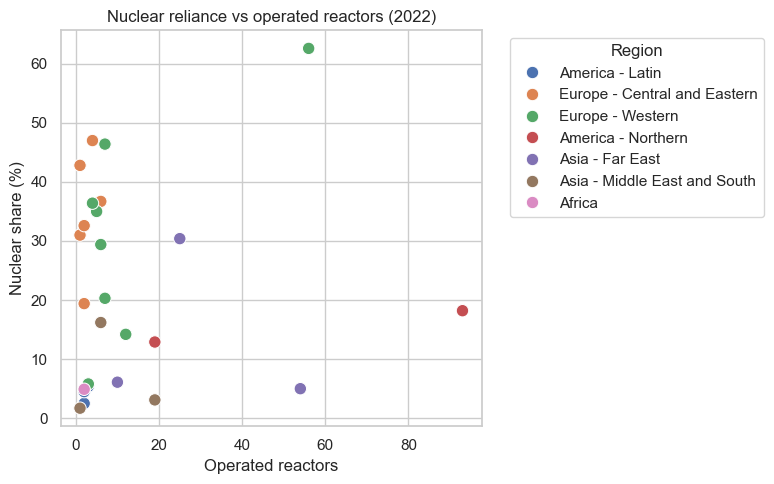

In [2]:
sns.scatterplot(data=merged, x='operated_reactors', y='nuclear_share_pct', hue='region', s=80)
plt.title('Nuclear reliance vs operated reactors (2022)')
plt.xlabel('Operated reactors')
plt.ylabel('Nuclear share (%)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Answer:** Nuclear share is not proportional to fleet size: Europe reaches high reliance with mid-sized fleets, while some large fleets in other regions still yield only moderate shares.

### Question: How concentrated are nuclear plant sites by region?

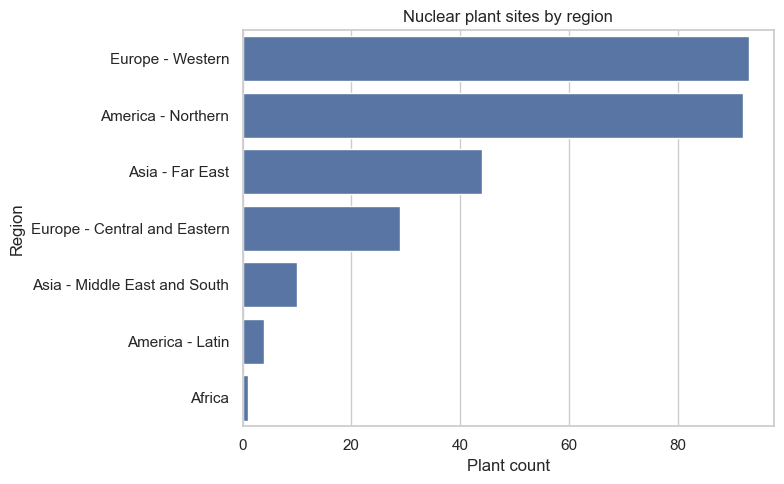

In [3]:
sns.countplot(data=plants, y='Region', order=plants['Region'].value_counts().index)
plt.title('Nuclear plant sites by region')
plt.xlabel('Plant count')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

**Answer:** Western Europe and Northern America host the majority of sites; Far East Asia follows distantly, and other regions have sparse coverage.

### Question: What is the distribution of nuclear share across countries?

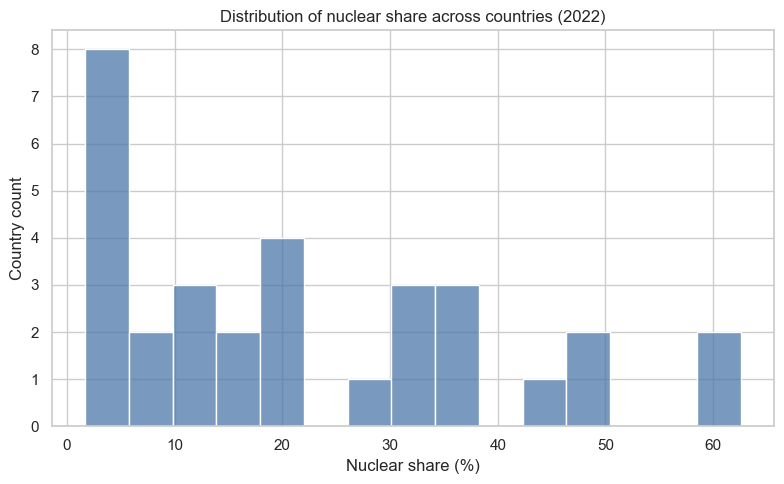

In [4]:
sns.histplot(merged['nuclear_share_pct'].dropna(), bins=15, kde=False, color='#4c78a8')
plt.title('Distribution of nuclear share across countries (2022)')
plt.xlabel('Nuclear share (%)')
plt.ylabel('Country count')
plt.tight_layout()
plt.show()

**Answer:** Most countries cluster below ~35% nuclear share, with a small tail above 50%, highlighting diverse energy mixes and policy choices.

## Key findings
- Europe achieves the highest nuclear reliance with mid-sized fleets, indicating policy mix matters more than sheer reactor count.-
- Plant infrastructure is heavily concentrated in Western Europe and Northern America, leaving other regions with sparse coverage.-
- Most countries rely on nuclear for under 35% of electricity; only a few exceed 50%.-

## Design reflections
- Used consistent color encoding for regions across plots for quick cross-reference.-
- Kept linear scales and labeled axes/units; annotations kept minimal to reduce clutter.-
- Faced small sample size (32 countries); avoided overplotting by modest marker sizes and clear binning.-

## Conclusion
Nuclear reliance is uneven: a few regions achieve high shares with moderate fleets, while many countries with small fleets rely minimally on nuclear. Infrastructure (site counts) is concentrated in Western Europe and Northern America. Policy and energy mix choices appear to matter more than sheer reactor counts.

## Reflection
If time allowed, I would add multi-year trend lines and incorporate capacity factor or outage data to strengthen the narrative. Feedback on color consistency and annotation density was incorporated; remaining risk is small sample size (32 countries).